In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")

x_validation = np.load("x_validation.npy")
y_validation = np.load("y_validation.npy")

x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("\nValidation images:", x_validation.shape)
print("Validation labels:", y_validation.shape)

print("\nTest images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (36400, 32, 32, 3)
Training labels: (36400, 24)

Validation images: (9100, 32, 32, 3)
Validation labels: (9100, 24)

Test images: (9100, 32, 32, 3)
Test labels: (9100, 24)


In [4]:
final_classes = [
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "horse",
    "truck",
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor",
    "trees"
]
num_classes = len(final_classes)

print("\nNumber of classes:", num_classes)


Number of classes: 24


In [5]:
assert y_train.shape[1] == 24
assert y_validation.shape[1] == 24
assert y_test.shape[1] == 24

print("Minimum pixel value in training set:", x_train.min())
print("Maximum pixel value in training set:", x_train.max())

Minimum pixel value in training set: 0.0
Maximum pixel value in training set: 1.0


In [6]:
baseline_accuracy = 0.6147
improved_accuracy = 0.7208

# Calculate class weight

In [7]:
y_train_integer = np.argmax(y_train, axis=1)

class_weight_array = compute_class_weight(
    class_weight='balanced',    
    classes = np.arange(num_classes),
    y = y_train_integer
)

class_weights = {class_index: weight for class_index, weight in enumerate(class_weight_array)}

print("Class Weights:\n")
for class_index, weight in class_weights.items():
    print(f"{class_index:2d} -"
    f" ({final_classes[class_index]:15s}):" 
    f" {weight:.4f}"
    )

Class Weights:

 0 - (automobile     ): 0.3792
 1 - (bird           ): 0.3792
 2 - (cat            ): 0.3792
 3 - (deer           ): 0.3792
 4 - (dog            ): 0.3792
 5 - (horse          ): 0.3792
 6 - (truck          ): 0.3792
 7 - (cattle         ): 3.7917
 8 - (fox            ): 3.7917
 9 - (baby           ): 3.7917
10 - (boy            ): 3.7917
11 - (girl           ): 3.7917
12 - (man            ): 3.7917
13 - (woman          ): 3.7917
14 - (rabbit         ): 3.7917
15 - (squirrel       ): 3.7917
16 - (bicycle        ): 0.7583
17 - (bus            ): 3.7917
18 - (motorcycle     ): 3.7917
19 - (pickup_truck   ): 3.7917
20 - (train          ): 3.7917
21 - (lawn_mower     ): 3.7917
22 - (tractor        ): 3.7917
23 - (trees          ): 3.7917


# Creating data augmentation

In [8]:
data_augmentation = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

print("Data augmentation pipeline created.")


Data augmentation pipeline created.


# Building data augmentation model

In [9]:
augmented_model = Sequential([
    Conv2D(32, 
    (3, 3), 
    activation='relu', 
    input_shape=(32, 32, 3)),
    BatchNormalization(),
    
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
augmented_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

augmented_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 626,424 (2.39 MB)

 Trainable params: 625,656 (2.39 MB)

 Non-trainable params: 768 (3.00 KB)

In [11]:
early_stopping_augmented = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Training Augmented Model

In [12]:
history_augmented = augmented_model.fit(
    data_augmentation.flow(
    x_train, 
    y_train, 
    batch_size=64,
    shuffle=True
    ),

    epochs= 40,
    validation_data=(x_validation, y_validation),
    class_weight=class_weights,
    callbacks=[early_stopping_augmented],
    verbose=1
)

Epoch 1/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1430 - loss: 3.1267 - val_accuracy: 0.1918 - val_loss: 2.5919
Epoch 2/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.2046 - loss: 2.5279 - val_accuracy: 0.2536 - val_loss: 2.4468
Epoch 3/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.2449 - loss: 2.3134 - val_accuracy: 0.2768 - val_loss: 2.2660
Epoch 4/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.2749 - loss: 2.1950 - val_accuracy: 0.2626 - val_loss: 2.3383
Epoch 5/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.2951 - loss: 2.1091 - val_accuracy: 0.3685 - val_loss: 1.9983
Epoch 6/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.3133 - loss: 2.0395 - val_accuracy: 0.2536 - val_loss: 2.4590
Epoch 7/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.3298 - loss: 1.9938 - val_accuracy: 0.3227 - val_loss: 2.0228
Epoch 8/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.3363 - loss: 1.9524 - 

# Evaluating the test set

In [13]:
augmented_test_loss, augmented_test_accuracy = augmented_model.evaluate(
 x_test,
 y_test, 
 verbose=1)

print(f"\nAugmented Model Test Loss: {augmented_test_loss:.4f}")
print(f"Augmented Model Test Accuracy: {augmented_test_accuracy:.4f}")
print(f"Augmented Model Test Accuracy:{augmented_test_accuracy * 100:.2f}%")

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5005 - loss: 1.5484

Augmented Model Test Loss: 1.5484
Augmented Model Test Accuracy: 0.5005
Augmented Model Test Accuracy:50.05%


# Plotting Accuracy

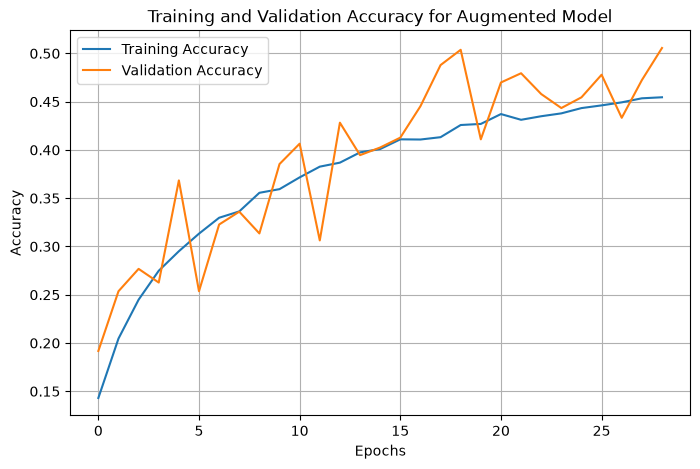

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history_augmented.history['accuracy'], label='Training Accuracy')

plt.plot(history_augmented.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Augmented Model')

plt.legend()
plt.grid(True)
plt.show()

# Plotting Loss

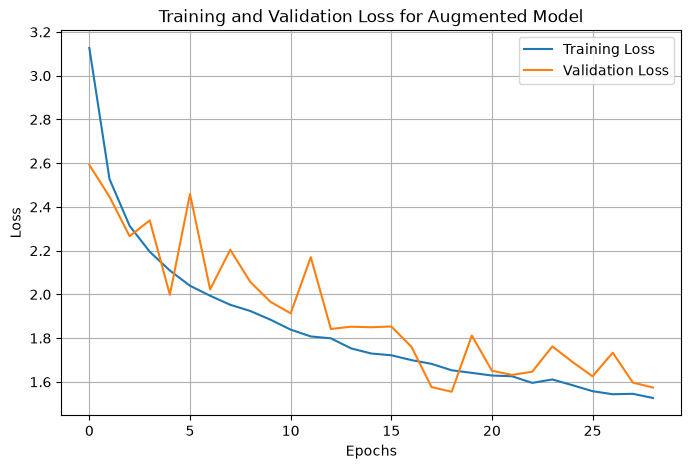

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_augmented.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_augmented.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Augmented Model')
plt.legend()
plt.grid(True)
plt.show()

# Generating predictions

In [16]:
prediction_augmented = augmented_model.predict(x_test, verbose=1)

prediction_labels = np.argmax(prediction_augmented, axis=1)

true_labels = np.argmax(y_test, axis=1)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


# Classification report

In [18]:
print(
classification_report(
    true_labels, 
    prediction_labels, 
    target_names=final_classes,
    digits=4
)
)

              precision    recall  f1-score   support

  automobile     0.8623    0.5950    0.7041      1000
        bird     0.8000    0.3120    0.4489      1000
         cat     0.5724    0.3520    0.4359      1000
        deer     0.7178    0.3840    0.5003      1000
         dog     0.5635    0.4970    0.5282      1000
       horse     0.6937    0.6250    0.6575      1000
       truck     0.8182    0.5850    0.6822      1000
      cattle     0.1491    0.3400    0.2073       100
         fox     0.1289    0.7000    0.2177       100
        baby     0.2895    0.3300    0.3084       100
         boy     0.2381    0.4000    0.2985       100
        girl     0.2025    0.1600    0.1788       100
         man     0.2391    0.1100    0.1507       100
       woman     0.1500    0.4800    0.2286       100
      rabbit     0.1685    0.1500    0.1587       100
    squirrel     0.1571    0.3300    0.2129       100
     bicycle     0.6889    0.8900    0.7766       500
         bus     0.3223    

# Confusion Matrix

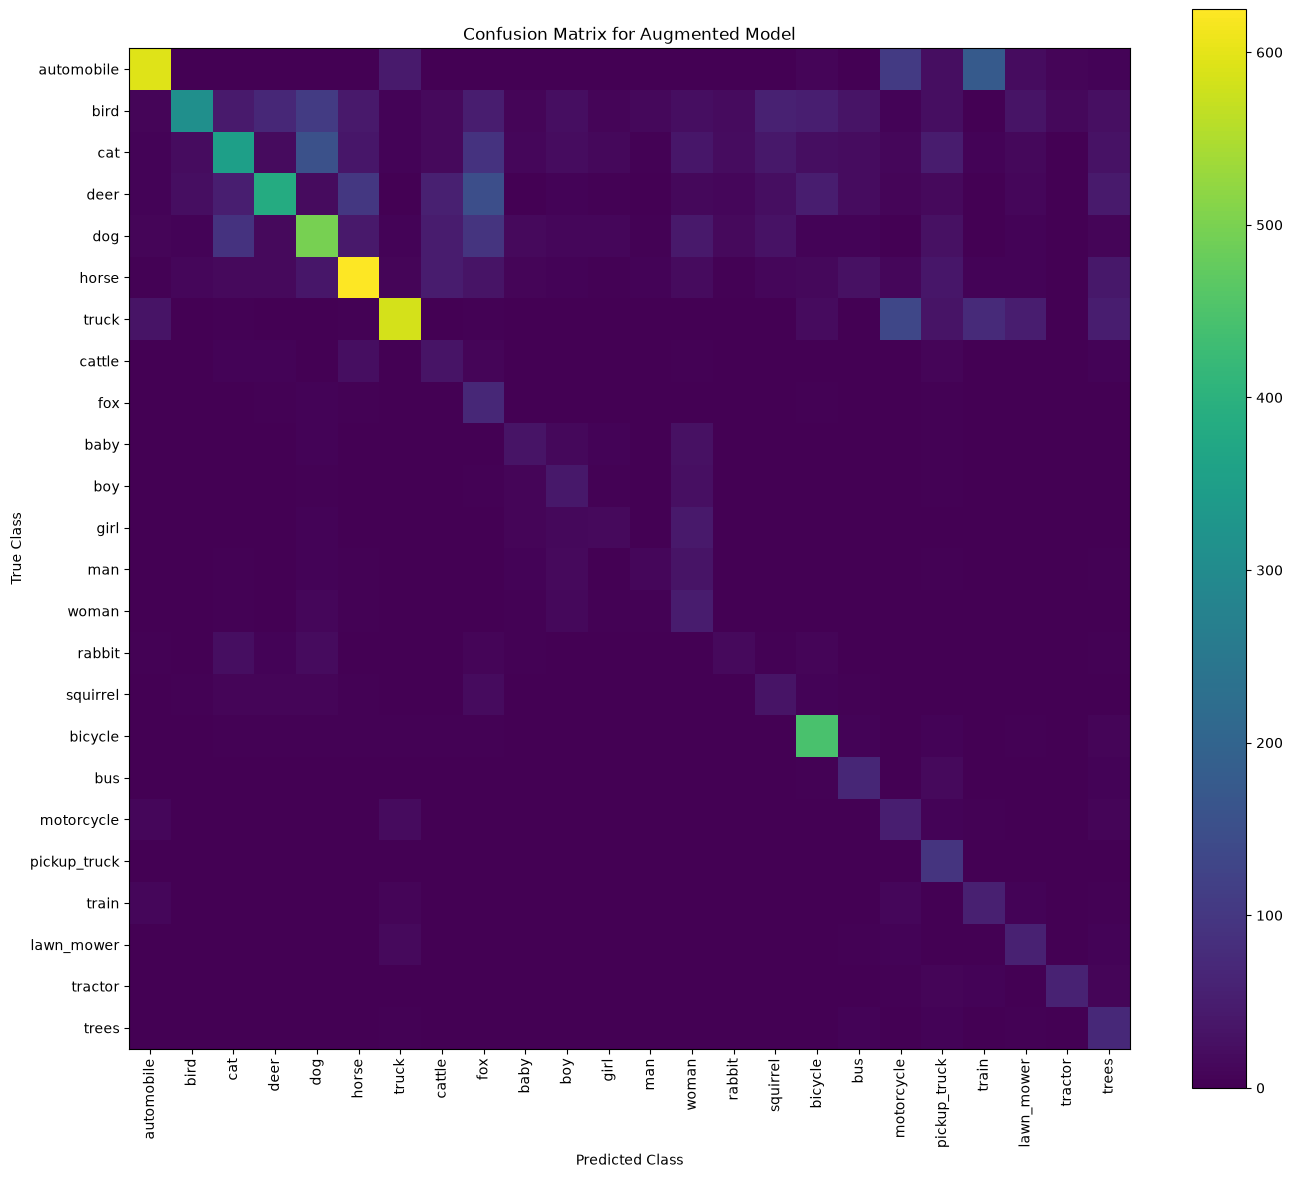

In [19]:
cm = confusion_matrix(
    true_labels,
    prediction_labels
)

plt.figure(figsize=(14, 12))

plt.imshow(
    cm,
    interpolation='nearest',
)

plt.title('Confusion Matrix for Augmented Model')
plt.colorbar()

tick_positions = np.arange(len(final_classes))

plt.xticks(tick_positions, final_classes, rotation=90)
plt.yticks(tick_positions, final_classes)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

In [20]:
augmented_model.save("augmented_model.keras")


# Comparing Model results

In [21]:
baseline_accuracy = 0.6147
improved_accuracy = 0.7208

model_names = [
    "Baseline Model",
    "Improved Model",
    "Augmented Model"
]

model_accuracies = [
    baseline_accuracy * 100,
    improved_accuracy * 100,
    augmented_test_accuracy * 100
]

print("\nModel Accuracies:\n")
for model_name, model_accuracy in zip(model_names, model_accuracies):
    print(f"{model_name:20s}: {model_accuracy:.2f}%")


Model Accuracies:

Baseline Model      : 61.47%
Improved Model      : 72.08%
Augmented Model     : 50.05%


# Comparison Chart

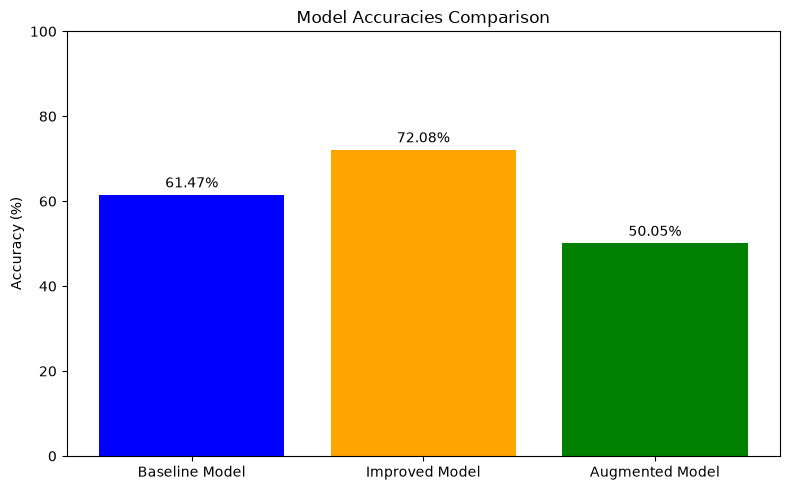

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(model_names, model_accuracies, color=['blue', 'orange', 'green'])

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracies Comparison")
plt.ylim(0, 100)

for index, accuracy in enumerate(model_accuracies):
    plt.text(
        index, 
        accuracy + 1, 
        f"{accuracy:.2f}%", 
        ha='center', 
        va='bottom'
    )

plt.tight_layout()
plt.show()

# Experimenting with a different augmented model

In [23]:
prediction_probabilities = augmented_model.predict(x_test, verbose=1)

prediction_labels = np.argmax(prediction_probabilities, axis=1)

true_labels = np.argmax(y_test, axis=1)

print(classification_report(
    true_labels, 
    prediction_labels, 
    target_names=final_classes,
    digits=4
)
)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

  automobile     0.8623    0.5950    0.7041      1000
        bird     0.8000    0.3120    0.4489      1000
         cat     0.5724    0.3520    0.4359      1000
        deer     0.7178    0.3840    0.5003      1000
         dog     0.5635    0.4970    0.5282      1000
       horse     0.6937    0.6250    0.6575      1000
       truck     0.8182    0.5850    0.6822      1000
      cattle     0.1491    0.3400    0.2073       100
         fox     0.1289    0.7000    0.2177       100
        baby     0.2895    0.3300    0.3084       100
         boy     0.2381    0.4000    0.2985       100
        girl     0.2025    0.1600    0.1788       100
         man     0.2391    0.1100    0.1507       100
       woman     0.1500    0.4800    0.2286       100
      rabbit     0.1685    0.1500    0.1587       100
    squirrel     0.1571    0.3300    0.2129       100
     bicycle     0.6889    0.8900    0.7

In [24]:
mild_augmentation = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
)

## Creating a new model

In [25]:
augmentation_only_model = Sequential([
    Conv2D(32, 
    (3, 3), 
    activation='relu', 
    input_shape=(32, 32, 3)),
    BatchNormalization(),
    
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

augmentation_only_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
early_stopping_mild = EarlyStopping(
    monitor='val_loss',
    patience= 6,
    restore_best_weights=True,
    verbose=1
)

In [27]:
history_augmentation_only = augmentation_only_model.fit(
    mild_augmentation.flow(
    x_train, 
    y_train, 
    batch_size=64,
    shuffle=True
    ),

    epochs= 40,
    validation_data=(x_validation, y_validation),
    callbacks=[early_stopping_mild],
    verbose=1
)

Epoch 1/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.2195 - loss: 2.9771 - val_accuracy: 0.2618 - val_loss: 2.4483
Epoch 2/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.3156 - loss: 2.2779 - val_accuracy: 0.3864 - val_loss: 1.9500
Epoch 3/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.3699 - loss: 2.0568 - val_accuracy: 0.3722 - val_loss: 1.9921
Epoch 4/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.4105 - loss: 1.9202 - val_accuracy: 0.4165 - val_loss: 1.8627
Epoch 5/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.4406 - loss: 1.8275 - val_accuracy: 0.4338 - val_loss: 1.7773
Epoch 6/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.4584 - loss: 1.7611 - val_accuracy: 0.3832 - val_loss: 1.9931
Epoch 7/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.4751 - loss: 1.6983 - val_accuracy: 0.4838 - val_loss: 1.6632
Epoch 8/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.4958 - loss: 1.6448 - 

In [28]:
mild_test_loss, mild_test_accuracy = augmentation_only_model.evaluate(
    x_test,
    y_test, 
    verbose=1)

print(f"\nMild Augmentation Model Test Loss: {mild_test_loss:.4f}")
print(f"Mild Augmentation Model Test Accuracy: {mild_test_accuracy*100:.2f}%")

285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6293 - loss: 1.1776

Mild Augmentation Model Test Loss: 1.1776
Mild Augmentation Model Test Accuracy: 62.93%


In [29]:
augmentation_only_model.save("best_model.keras")

# Final Classification Report

In [31]:
prediction_probabilities = augmentation_only_model.predict(x_test)

prediction_labels = np.argmax(prediction_probabilities, axis=1)
true_labels = np.argmax(y_test, axis=1)

print(
    classification_report(
        true_labels,
        prediction_labels,
        target_names=final_classes,
        digits=4
    )
)

285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

  automobile     0.8249    0.8340    0.8294      1000
        bird     0.7246    0.5630    0.6337      1000
         cat     0.4730    0.6470    0.5465      1000
        deer     0.6265    0.7380    0.6777      1000
         dog     0.6988    0.5290    0.6022      1000
       horse     0.6814    0.7850    0.7296      1000
       truck     0.6960    0.8540    0.7670      1000
      cattle     0.0000    0.0000    0.0000       100
         fox     0.4286    0.0300    0.0561       100
        baby     0.2826    0.1300    0.1781       100
         boy     0.2516    0.4000    0.3089       100
        girl     0.3333    0.0200    0.0377       100
         man     0.3478    0.0800    0.1301       100
       woman     0.2093    0.1800    0.1935       100
      rabbit     0.0000    0.0000    0.0000       100
    squirrel     0.0000    0.0000    0.0000       100
     bicycle     0.7496    0.8980    0.8

c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# Final Confusion Matrix

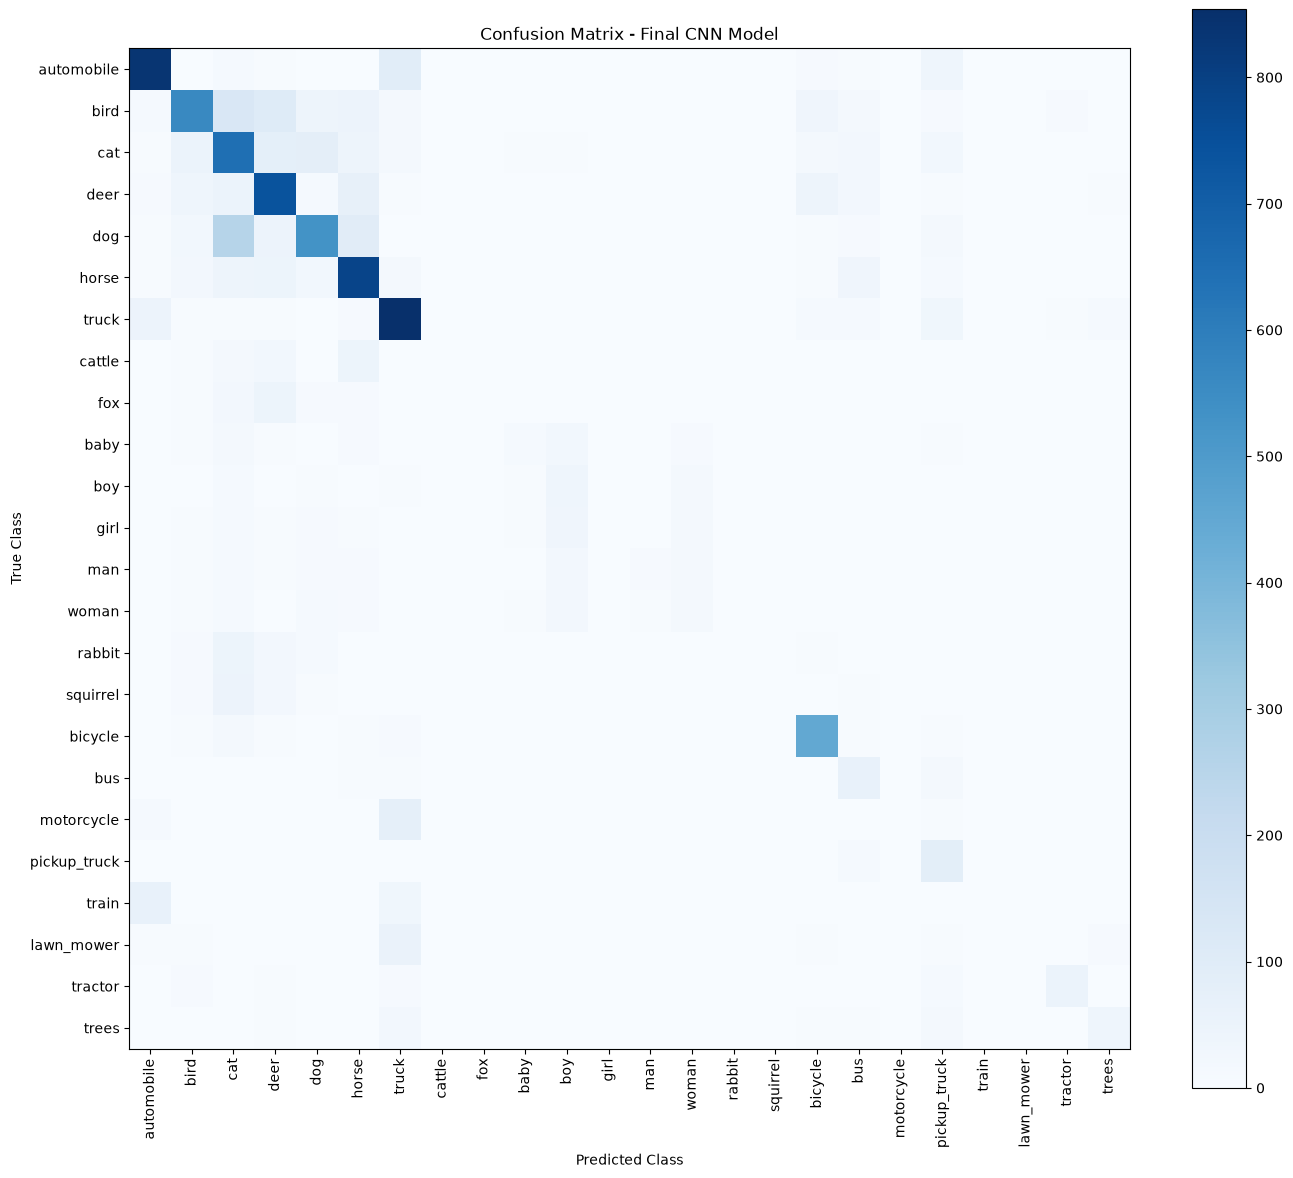

In [32]:
cm = confusion_matrix(
    true_labels,
    prediction_labels
)

plt.figure(figsize=(14, 12))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(final_classes)),
    final_classes,
    rotation=90
)

plt.yticks(
    np.arange(len(final_classes)),
    final_classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Final CNN Model")

plt.tight_layout()
plt.show()

# Final Comparison Graph

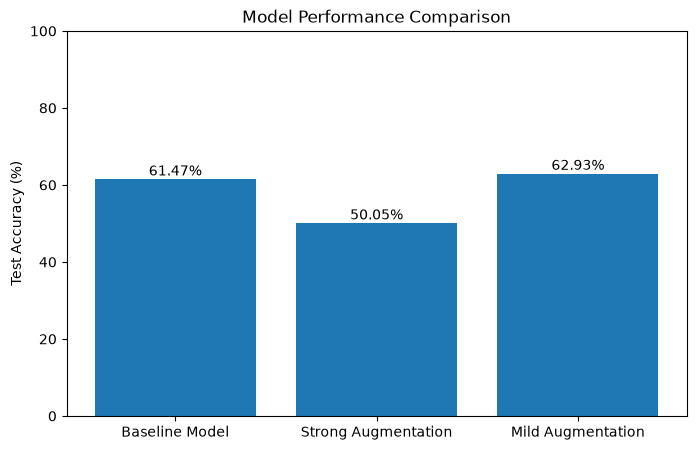

In [33]:
model_names = [
    "Baseline Model",
    "Strong Augmentation",
    "Mild Augmentation"
]

accuracies = [
    61.47,
    50.05,
    62.93
]

plt.figure(figsize=(8,5))

bars = plt.bar(model_names, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Model Performance Comparison")
plt.ylim(0,100)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.show()